# Trial of Network Evolution

In [30]:
from qsim.state import DensityMatrix
from qsim.lin_alg import TOperator, Operator
from qsim.dynamics import IVPPropagator, GKSLGenerator, Dynamics, ExponentialPropagator, HamiltonianGenerator, RK4Propagator, LiouvillianGenerator
from qsim.lin_alg.transforms import unvectorise, vectorise
from qsim.logging import Logger

from qtransfer.network import Network, ControlSequence

import networkx as nx

import numpy as np
import matplotlib.pyplot as plt

In [31]:
n = 4
p = 0.2

def get_adjacency(n, p):
    return nx.to_numpy_array(nx.erdos_renyi_graph(n , p , seed = None)).astype(np.complex128)

A = get_adjacency(n, p)
A

array([[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]])

In [32]:
control_times = [i for i in range(40)]

In [33]:
adjustments = [get_adjacency(n,0.5) for i in range(len(control_times))]

In [34]:
control = ControlSequence(control_times, adjustments)

In [35]:
rho0 = np.zeros(shape=(n,n)).astype(complex)
rho0[0][0] = 1
rho0 = DensityMatrix(rho0)

In [36]:
net = Network(A, rho0, control, [1], [1], [0.2 for i in range(n)])

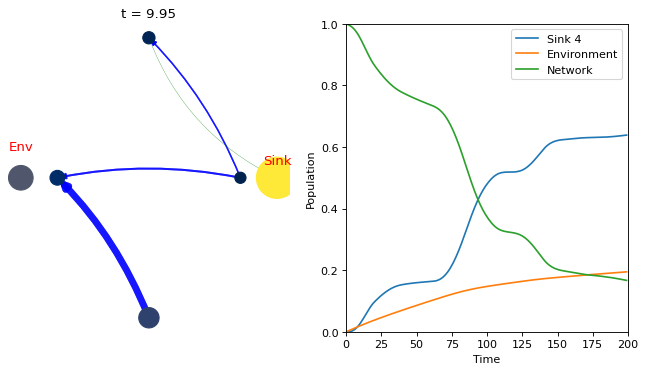

In [37]:
ts = 0.05
n_steps=200
net.animateEvolutionWithExcitationFlow(ts, n_steps)

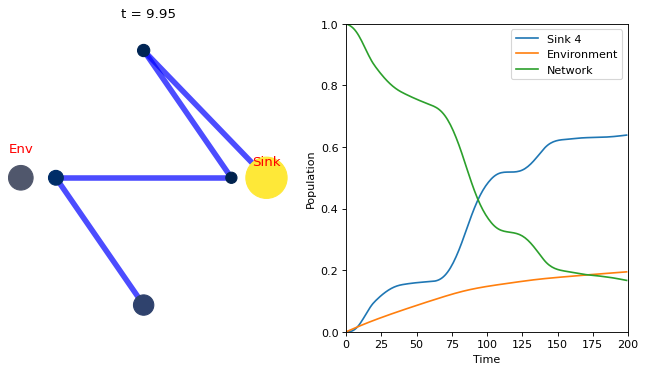

In [38]:
ts = 0.05
n_steps=200
net.animateEvolutionWithConnections(ts, n_steps)

In [39]:
net.energy_transfer

np.complex128(0.5387985627279519+5.202476362035913e-18j)